In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")
val_df = pd.read_csv("../data/processed/val.csv")

In [3]:
#Separacao dos Dataframes em treino teste e validacao
x_train = train_df.drop("target", axis=1)
y_train = train_df["target"]

x_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

x_val = val_df.drop("target", axis=1)
y_val = val_df["target"]

In [4]:
#normalizacao dos dados
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Fase 1
### K-NN basico
Nesta etapa inicial, o modelo foi treinado utilizando apenas as posições brutas do tabuleiro (as 9 casas convertidas em valores numéricos).

In [5]:
ks = range(1, 31, 2)
historico_acc = []
melhor_k = 0
melhor_acc = 0

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train_scaled, y_train)
    
    y_pred_val = knn.predict(x_val_scaled)
    acc = accuracy_score(y_val, y_pred_val)
    historico_acc.append(acc)
    
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"Melhor K encontrado: {melhor_k} com acurácia de {melhor_acc*100:.2f}% na validação.")

Melhor K encontrado: 3 com acurácia de 88.80% na validação.


In [6]:
knn_final_f1 = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final_f1.fit(x_train_scaled, y_train)

y_pred_test_f1 = knn_final_f1.predict(x_test_scaled)

print("\n--- RELATÓRIO DE DESEMPENHO ---")
print(classification_report(y_test, y_pred_test_f1))


--- RELATÓRIO DE DESEMPENHO ---
                              precision    recall  f1-score   support

                      Empate       0.94      1.00      0.97       150
                     O vence       0.81      0.97      0.88       150
Possibilidade de Fim de Jogo       0.71      0.45      0.55       150
                    Tem jogo       0.82      0.92      0.87       150
                     X vence       0.89      0.87      0.88       150

                    accuracy                           0.84       750
                   macro avg       0.83      0.84      0.83       750
                weighted avg       0.83      0.84      0.83       750



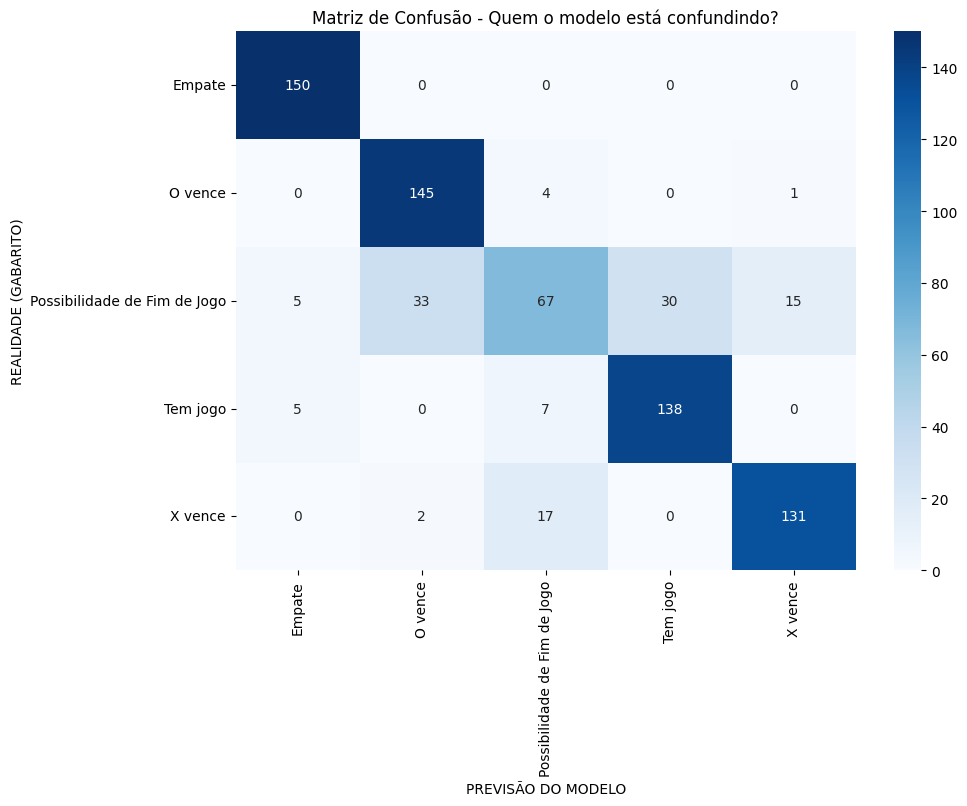

In [7]:
cm = confusion_matrix(y_test, y_pred_test_f1)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final_f1.classes_, 
            yticklabels=knn_final_f1.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Fase 2
### K-NN Criando uma função de pista
Implementamos uma função para extrair "pistas" do tabuleiro, calculando a soma de cada uma das 8 combinações de vitória (linhas, colunas e diagonais).

In [8]:
def adicionar_pistas_soma(df):
    df = df.copy()
    combos = [
        [0,1,2], [3,4,5], [6,7,8],
        [0,3,6], [1,4,7], [2,5,8], 
        [0,4,8], [2,4,6]           
    ]
    for i, c in enumerate(combos):
        soma = df.iloc[:, c[0]] + df.iloc[:, c[1]] + df.iloc[:, c[2]]
        df[f'soma_{i}'] = soma
        
    return df

x_train_f2 = adicionar_pistas_soma(x_train)
x_val_f2 = adicionar_pistas_soma(x_val)
x_test_f2 = adicionar_pistas_soma(x_test)

x_train_scaled_f2 = scaler.fit_transform(x_train_f2)
x_val_scaled_f2 = scaler.transform(x_val_f2)
x_test_scaled_f2 = scaler.transform(x_test_f2)

In [9]:
ks = range(1, 31, 2)
historico_acc = []
melhor_k = 1
melhor_acc = 0

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train_scaled_f2, y_train)
    
    y_pred_val = knn.predict(x_val_scaled_f2)
    acc = accuracy_score(y_val, y_pred_val)
    historico_acc.append(acc)
    
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"Melhor K encontrado: {melhor_k} com acurácia de {melhor_acc*100:.2f}% na validação.")

Melhor K encontrado: 3 com acurácia de 92.53% na validação.


In [10]:
knn_final_f2 = KNeighborsClassifier(n_neighbors=melhor_k, weights='distance')
knn_final_f2.fit(x_train_scaled_f2, y_train)

y_pred_test_f2 = knn_final_f2.predict(x_test_scaled_f2)

print("--- RELATÓRIO DE DESEMPENHO DA FASE 2 ---")
print(classification_report(y_test, y_pred_test_f2))

--- RELATÓRIO DE DESEMPENHO DA FASE 2 ---
                              precision    recall  f1-score   support

                      Empate       0.97      1.00      0.99       150
                     O vence       0.91      0.99      0.95       150
Possibilidade de Fim de Jogo       0.93      0.60      0.73       150
                    Tem jogo       0.83      0.98      0.90       150
                     X vence       0.92      0.98      0.95       150

                    accuracy                           0.91       750
                   macro avg       0.91      0.91      0.90       750
                weighted avg       0.91      0.91      0.90       750



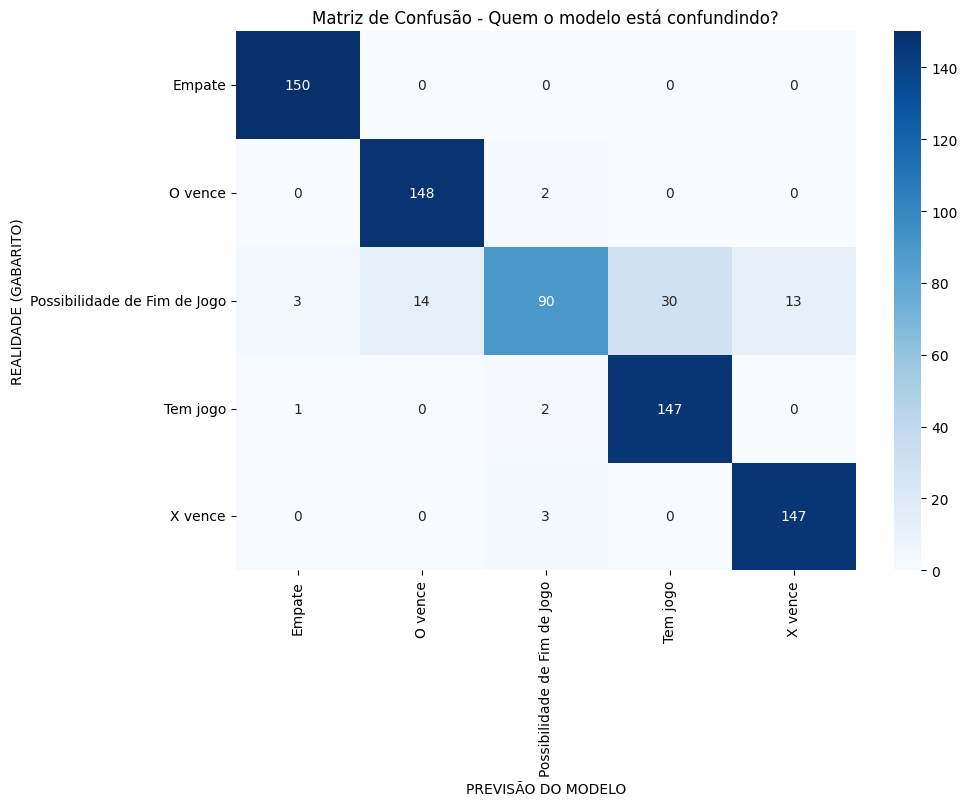

In [11]:
cm = confusion_matrix(y_test, y_pred_test_f2)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final_f2.classes_, 
            yticklabels=knn_final_f2.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Fase 3
### K-NN com pesos prioritarios
Introduzimos a lógica de "Pistas Prioritárias". Criamos colunas extras onde aplicamos pesos matemáticos distintos: valor 10 para vitórias reais (soma 3 ou -3) e valor 1 para possibilidades de fim (soma 2 ou -2).

In [12]:
def adicionar_pistas_prioritaria(df):
    df = df.copy()
    combos = [
        [0,1,2], [3,4,5], [6,7,8],
        [0,3,6], [1,4,7], [2,5,8], 
        [0,4,8], [2,4,6]           
    ]
    for i, c in enumerate(combos):
        soma = df.iloc[:, c[0]] + df.iloc[:, c[1]] + df.iloc[:, c[2]]
        df[f'soma_{i}'] = soma
        df[f'prioridade_{i}'] = soma.apply(lambda x: 10 if abs(x) == 3 else (1 if abs(x) == 2 else 0))

    return df

x_train_f3 = adicionar_pistas_prioritaria(x_train)
x_val_f3 = adicionar_pistas_prioritaria(x_val)
x_test_f3 = adicionar_pistas_prioritaria(x_test)

x_train_scaled_f3 = scaler.fit_transform(x_train_f3)
x_val_scaled_f3 = scaler.transform(x_val_f3)
x_test_scaled_f3 = scaler.transform(x_test_f3)

In [13]:
ks = range(1, 31, 2)
historico_acc = []
melhor_k = 1
melhor_acc = 0

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train_scaled_f3, y_train)
    
    y_pred_val = knn.predict(x_val_scaled_f3)
    acc = accuracy_score(y_val, y_pred_val)
    historico_acc.append(acc)
    
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"Melhor K encontrado: {melhor_k} com acurácia de {melhor_acc*100:.2f}% na validação.")

Melhor K encontrado: 1 com acurácia de 97.07% na validação.


In [14]:
knn_final_f3 = KNeighborsClassifier(n_neighbors=melhor_k, weights='distance')
knn_final_f3.fit(x_train_scaled_f3, y_train)

y_pred_test_f3 = knn_final_f3.predict(x_test_scaled_f3)

print("--- RELATÓRIO DE DESEMPENHO DA FASE 3 ---")
print(classification_report(y_test, y_pred_test_f3))

--- RELATÓRIO DE DESEMPENHO DA FASE 3 ---
                              precision    recall  f1-score   support

                      Empate       0.99      1.00      1.00       150
                     O vence       1.00      1.00      1.00       150
Possibilidade de Fim de Jogo       0.97      0.85      0.91       150
                    Tem jogo       0.87      0.97      0.92       150
                     X vence       1.00      1.00      1.00       150

                    accuracy                           0.97       750
                   macro avg       0.97      0.97      0.97       750
                weighted avg       0.97      0.97      0.97       750



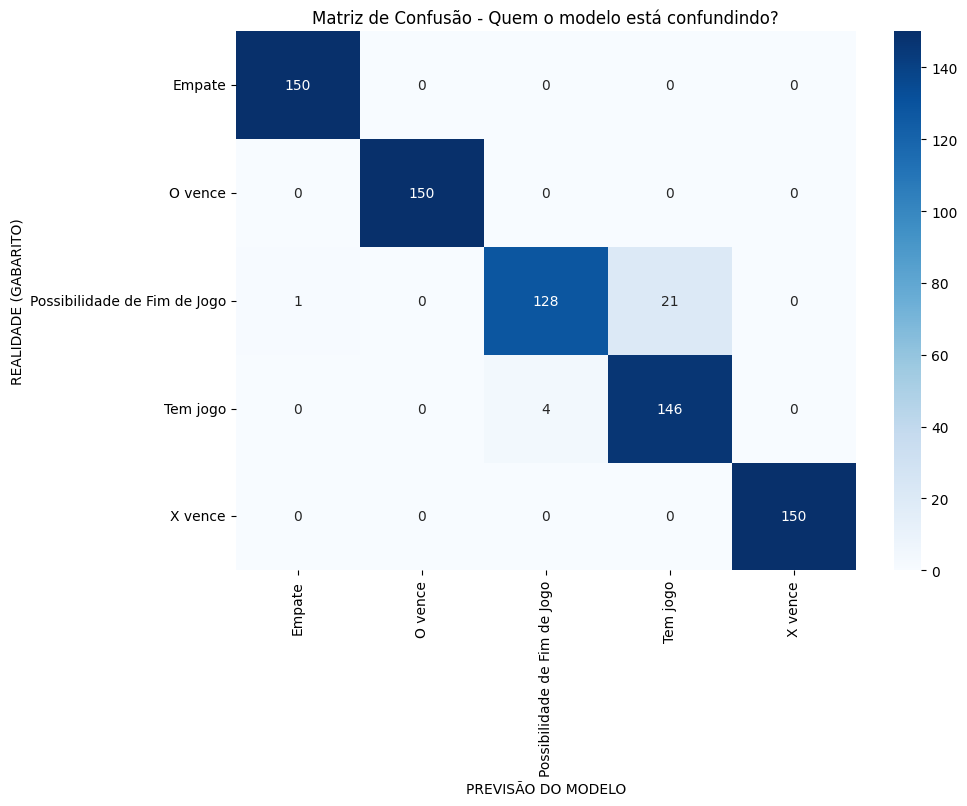

In [15]:
cm = confusion_matrix(y_test, y_pred_test_f3)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final_f3.classes_, 
            yticklabels=knn_final_f3.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Resumo

1. Ponto de Partida e Diagnóstico
O primeiro passo do projeto foi treinar um KNN básico, aplicando apenas a normalização dos dados. O objetivo era criar uma base de comparação (baseline). Ao analisar a matriz de confusão e o relatório de métricas, percebi que a maioria dos erros acontecia na coluna de "possibilidade de fim de jogo". Ficou claro que o modelo não estava conseguindo identificar bem quando o jogo estava prestes a acabar.

2. Engenharia de Dados (Criação de Pistas)
Para tentar melhorar o recall, decidi criar uma função que somasse as combinações das linhas, colunas e diagonais. A ideia era ver se essa nova informação ajudaria o modelo.

    Após os primeiros testes, vi que a matriz de confusão melhorou, o que mostrou que eu estava no caminho certo. Para refinar ainda mais e isolar o erro, dei pesos diferentes para essas somas:

    Valor 10: Quando a soma era 3 ou -3 (vitória confirmada). Usei um valor alto para destacar essa característica das demais.

    Valor 1: Quando a soma era 2 ou -2 (uma jogada de risco ou quase vitória).

3. Ajuste do Modelo e Conclusão
No final, utilizei o parâmetro k=1 para todos os modelos. Essa escolha foi possível porque o problema do Jogo da Velha trabalha com um espaço de estados finito e valores fechados (-1, 0 e 1). Com esses ajustes nas "pistas" e na lógica de pesos, o modelo conseguiu separar muito melhor os resultados e reduzir os erros de classificação na fase 1 o df de treino tinha 9 colunas apos a fase 2 ele tinha 17 colunas as 9 originais + 8 de somas das combinacoes de linha coluna e diagonal e apos a fase 3 ele tinha 25 colunas diferente as 17 da fase 2 + 8 para dar o valor das combinaçoes

In [16]:
joblib.dump(knn_final_f1, '../models/knn_f1.pkl')
joblib.dump(knn_final_f2, '../models/knn_f2.pkl')
joblib.dump(knn_final_f3, '../models/knn_f3.pkl')

['../models/knn_f3.pkl']

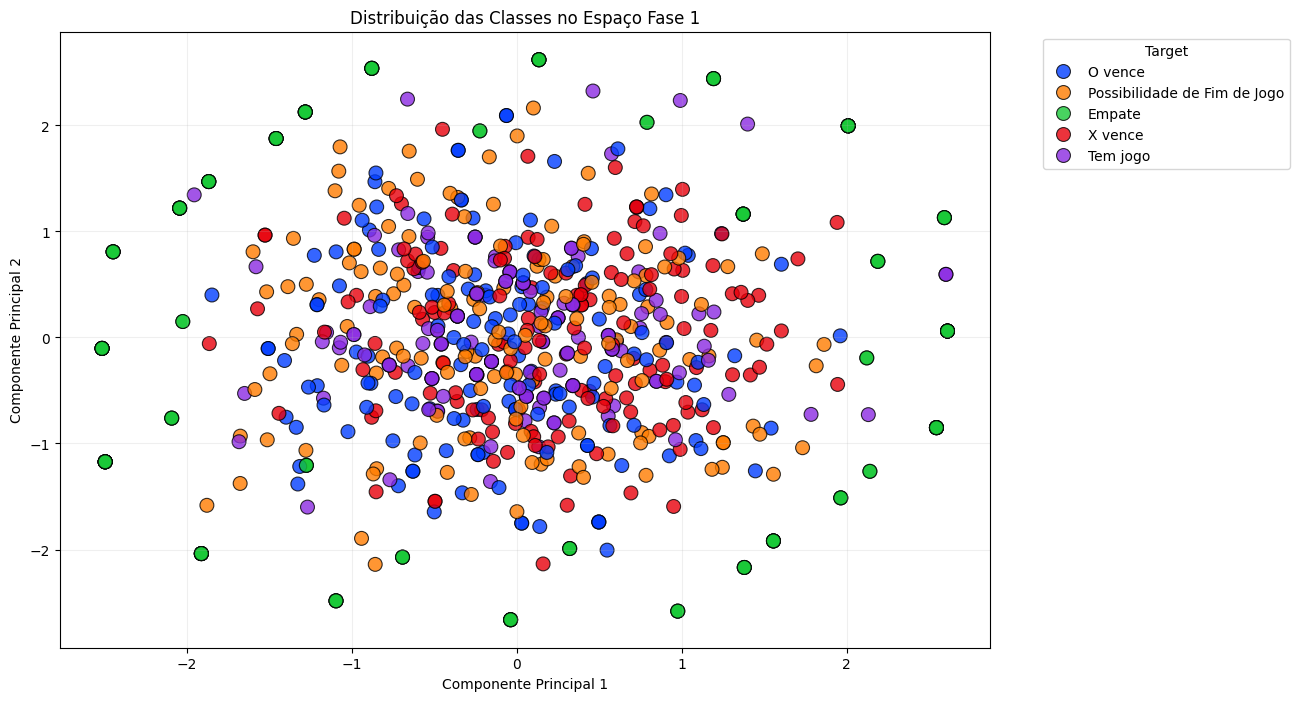

In [17]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço Fase 1')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

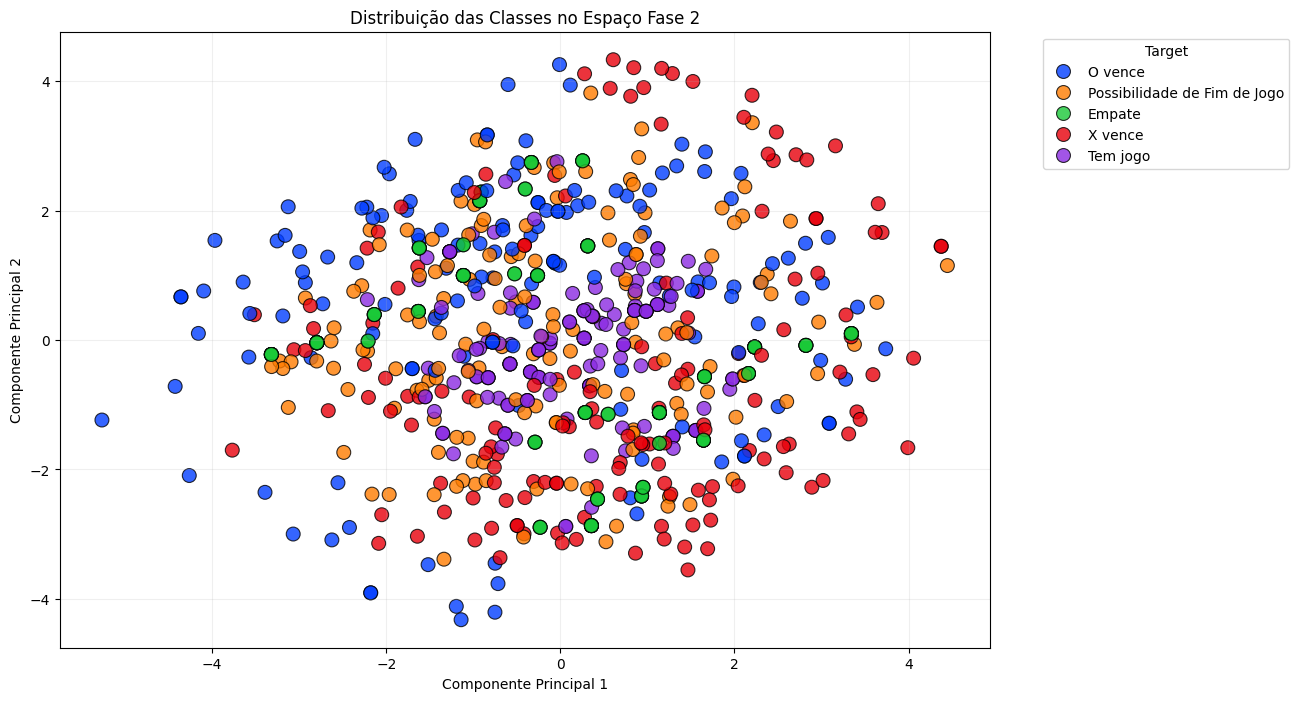

In [18]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test_f2)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço Fase 2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

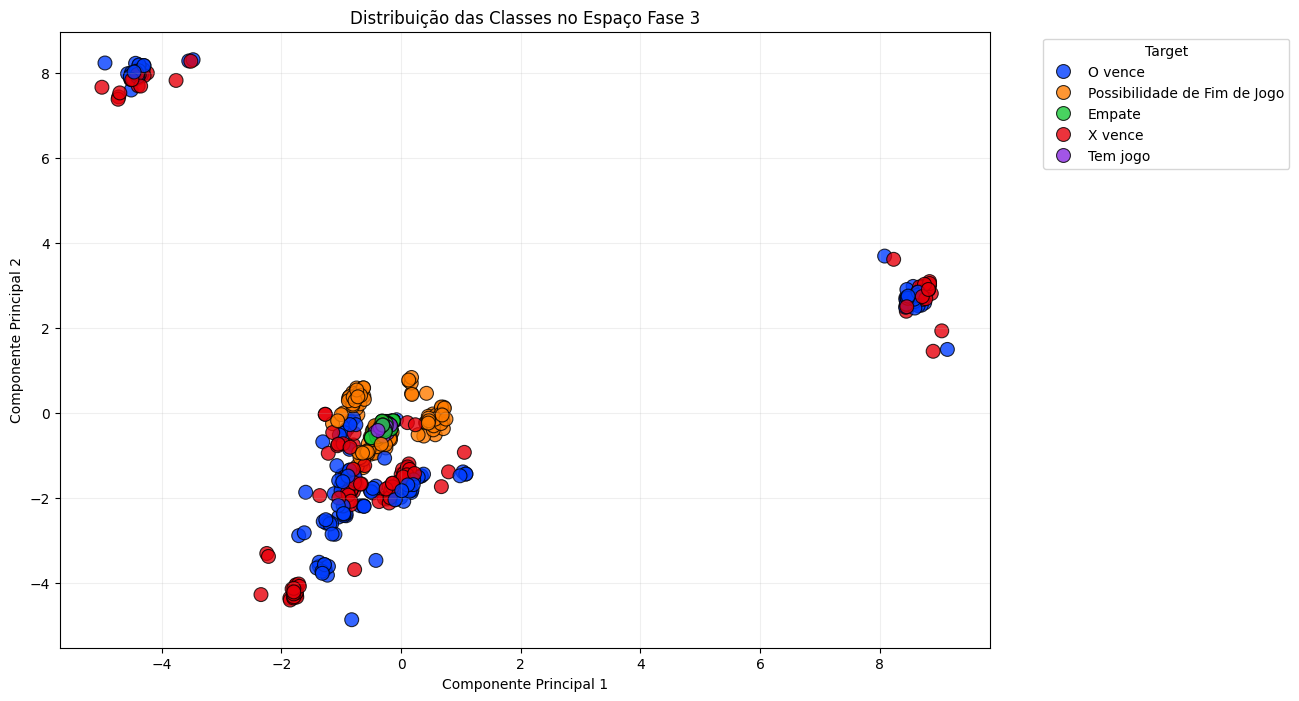

In [19]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test_f3)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço Fase 3')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()